# First Data Exploration with pandas

## Purpose

Use pandas to load, inspect, filter, summarise and lightly visualise a small tabular dataset.

This is not about machine learning yet. The goal is to get comfortable with the kind of data inspection work that usually happens before any modelling.

## 1. Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
pd.__version__

'3.0.2'

## 2. Initial locally defined dataset

In [2]:
data = [
    {"student": "Asha", "hours_studied": 2.5, "practice_questions": 12, "score": 58, "passed": True},
    {"student": "Ben", "hours_studied": 1.0, "practice_questions": 5, "score": 42, "passed": False},
    {"student": "Cara", "hours_studied": 4.0, "practice_questions": 20, "score": 76, "passed": True},
    {"student": "Dan", "hours_studied": 3.5, "practice_questions": 16, "score": 69, "passed": True},
    {"student": "Eli", "hours_studied": 0.5, "practice_questions": 3, "score": 35, "passed": False},
    {"student": "Fran", "hours_studied": 5.0, "practice_questions": 24, "score": 88, "passed": True},
    {"student": "Gita", "hours_studied": 2.0, "practice_questions": 10, "score": 53, "passed": True},
    {"student": "Hugo", "hours_studied": 1.5, "practice_questions": 8, "score": 47, "passed": False},
]

df = pd.DataFrame(data)
df

,student,hours_studied,practice_questions,score,passed
0,Asha,2.5,12,58,True
1,Ben,1.0,5,42,False
2,Cara,4.0,20,76,True
3,Dan,3.5,16,69,True
4,Eli,0.5,3,35,False
5,Fran,5.0,24,88,True
6,Gita,2.0,10,53,True
7,Hugo,1.5,8,47,False


A DataFrame is a two-dimensional table with labelled columns.

This is the basic pandas object I will usually use when working with tabular data.

## 3. First inspection

In [3]:
df.head()

,student,hours_studied,practice_questions,score,passed
0,Asha,2.5,12,58,True
1,Ben,1.0,5,42,False
2,Cara,4.0,20,76,True
3,Dan,3.5,16,69,True
4,Eli,0.5,3,35,False


In [4]:
df.shape

(8, 5)

In [5]:
df.columns

Index(['student', 'hours_studied', 'practice_questions', 'score', 'passed'], dtype='str')

In [6]:
df.dtypes

student                   str
hours_studied         float64
practice_questions      int64
score                   int64
passed                   bool
dtype: object

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   student             8 non-null      str    
 1   hours_studied       8 non-null      float64
 2   practice_questions  8 non-null      int64  
 3   score               8 non-null      int64  
 4   passed              8 non-null      bool   
dtypes: bool(1), float64(1), int64(2), str(1)
memory usage: 396.0 bytes


Useful first questions:

- How many rows and columns are there?
- What are the column names?
- What data type does pandas think each column contains?
- Are any values missing?

## 4. Basic summary statistics

In [8]:
df.describe()

,hours_studied,practice_questions,score
count,8.000000,8.000000,8.000000
mean,2.500000,12.250000,58.500000
std,1.558387,7.304597,18.023794
min,0.500000,3.000000,35.000000
25%,1.375000,7.250000,45.750000
50%,2.250000,11.000000,55.500000
75%,3.625000,17.000000,70.750000
max,5.000000,24.000000,88.000000


In [9]:
df["score"].mean()

np.float64(58.5)

In [10]:
df["score"].min(), df["score"].max()

(np.int64(35), np.int64(88))

In [11]:
df[["hours_studied", "practice_questions", "score"]].mean()

hours_studied          2.50
practice_questions    12.25
score                 58.50
dtype: float64

`describe()` gives a fast numerical overview.

It is not a substitute for thinking, but it is a useful first scan.

## 5. Selecting columns

In [12]:
df["score"]

0    58
1    42
2    76
3    69
4    35
5    88
6    53
7    47
Name: score, dtype: int64

In [13]:
df[["student", "score"]]

,student,score
0,Asha,58
1,Ben,42
2,Cara,76
3,Dan,69
4,Eli,35
5,Fran,88
6,Gita,53
7,Hugo,47


In [14]:
study_columns = df[["hours_studied", "practice_questions", "score"]]
study_columns

,hours_studied,practice_questions,score
0,2.5,12,58
1,1.0,5,42
2,4.0,20,76
3,3.5,16,69
4,0.5,3,35
5,5.0,24,88
6,2.0,10,53
7,1.5,8,47


Single square brackets select one column.

Double square brackets select a list of columns and return another DataFrame.

## 6. Filtering rows

In [15]:
df[df["passed"] == True]

,student,hours_studied,practice_questions,score,passed
0,Asha,2.5,12,58,True
2,Cara,4.0,20,76,True
3,Dan,3.5,16,69,True
5,Fran,5.0,24,88,True
6,Gita,2.0,10,53,True


In [16]:
df[df["passed"]]

,student,hours_studied,practice_questions,score,passed
0,Asha,2.5,12,58,True
2,Cara,4.0,20,76,True
3,Dan,3.5,16,69,True
5,Fran,5.0,24,88,True
6,Gita,2.0,10,53,True


In [17]:
df[df["score"] >= 60]

,student,hours_studied,practice_questions,score,passed
2,Cara,4.0,20,76,True
3,Dan,3.5,16,69,True
5,Fran,5.0,24,88,True


In [18]:
df[df["hours_studied"] >= 3]

,student,hours_studied,practice_questions,score,passed
2,Cara,4.0,20,76,True
3,Dan,3.5,16,69,True
5,Fran,5.0,24,88,True


In [19]:
df[(df["hours_studied"] >= 3) & (df["score"] >= 60)]

,student,hours_studied,practice_questions,score,passed
2,Cara,4.0,20,76,True
3,Dan,3.5,16,69,True
5,Fran,5.0,24,88,True


Filtering lets me ask simple questions of the data.

The result is still a DataFrame, just with fewer rows.

### Important note

When combining conditions in pandas:

- use `&` for AND
- use `|` for OR
- wrap each condition in parentheses

## 7. Sorting

In [20]:
df.sort_values("score")

,student,hours_studied,practice_questions,score,passed
4,Eli,0.5,3,35,False
1,Ben,1.0,5,42,False
7,Hugo,1.5,8,47,False
6,Gita,2.0,10,53,True
0,Asha,2.5,12,58,True
3,Dan,3.5,16,69,True
2,Cara,4.0,20,76,True
5,Fran,5.0,24,88,True


In [21]:
df.sort_values("score", ascending=False)

,student,hours_studied,practice_questions,score,passed
5,Fran,5.0,24,88,True
2,Cara,4.0,20,76,True
3,Dan,3.5,16,69,True
0,Asha,2.5,12,58,True
6,Gita,2.0,10,53,True
7,Hugo,1.5,8,47,False
1,Ben,1.0,5,42,False
4,Eli,0.5,3,35,False


In [22]:
df.sort_values(["passed", "score"], ascending=[False, False])

,student,hours_studied,practice_questions,score,passed
5,Fran,5.0,24,88,True
2,Cara,4.0,20,76,True
3,Dan,3.5,16,69,True
0,Asha,2.5,12,58,True
6,Gita,2.0,10,53,True
7,Hugo,1.5,8,47,False
1,Ben,1.0,5,42,False
4,Eli,0.5,3,35,False


Sorting is often useful before looking at the "top" or "bottom" examples in a dataset.

## 8. Creating a derived column

In [23]:
df["questions_per_hour"] = df["practice_questions"] / df["hours_studied"]
df

,student,hours_studied,practice_questions,score,passed,questions_per_hour
0,Asha,2.5,12,58,True,4.800000
1,Ben,1.0,5,42,False,5.000000
2,Cara,4.0,20,76,True,5.000000
3,Dan,3.5,16,69,True,4.571429
4,Eli,0.5,3,35,False,6.000000
5,Fran,5.0,24,88,True,4.800000
6,Gita,2.0,10,53,True,5.000000
7,Hugo,1.5,8,47,False,5.333333


In [24]:
df["study_intensity"] = df["practice_questions"] / df["hours_studied"]
df[["student", "hours_studied", "practice_questions", "study_intensity"]]

,student,hours_studied,practice_questions,study_intensity
0,Asha,2.5,12,4.800000
1,Ben,1.0,5,5.000000
2,Cara,4.0,20,5.000000
3,Dan,3.5,16,4.571429
4,Eli,0.5,3,6.000000
5,Fran,5.0,24,4.800000
6,Gita,2.0,10,5.000000
7,Hugo,1.5,8,5.333333


A derived column is a new column calculated from existing columns.

This is a common early data-preparation step.

## 9. Grouping and summarising

In [25]:
df.groupby("passed")["score"].mean()

passed
False    41.333333
True     68.800000
Name: score, dtype: float64

In [26]:
df.groupby("passed")[["hours_studied", "practice_questions", "score"]].mean()

,hours_studied,practice_questions,score
passed,,,
False,1.0,5.333333,41.333333
True,3.4,16.400000,68.800000


In [27]:
df.groupby("passed").agg(
    average_score=("score", "mean"),
    average_hours=("hours_studied", "mean"),
    average_questions=("practice_questions", "mean"),
    count=("student", "count"),
)

,average_score,average_hours,average_questions,count
passed,,,,
False,41.333333,1.0,5.333333,3
True,68.800000,3.4,16.400000,5


Grouping lets me compare subsets of the data.

Here, I am comparing students who passed with students who did not.

## 10. Simple visual checks

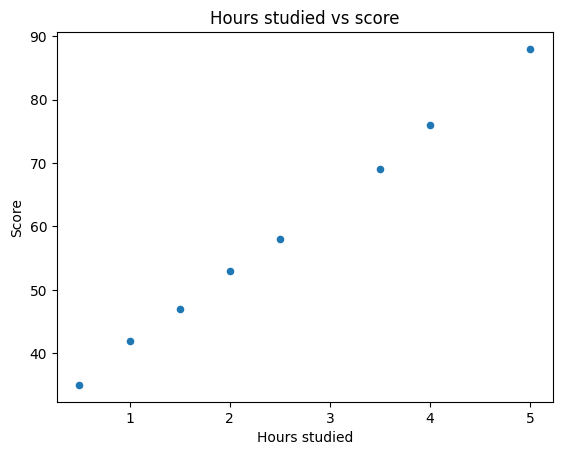

In [28]:
df.plot.scatter(x="hours_studied", y="score")
plt.title("Hours studied vs score")
plt.xlabel("Hours studied")
plt.ylabel("Score")
plt.show()

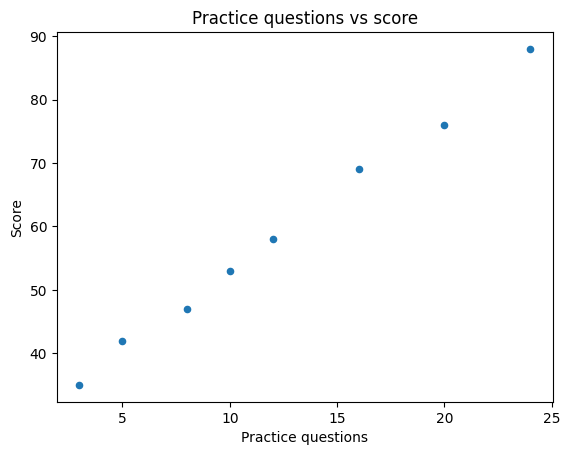

In [29]:
df.plot.scatter(x="practice_questions", y="score")
plt.title("Practice questions vs score")
plt.xlabel("Practice questions")
plt.ylabel("Score")
plt.show()

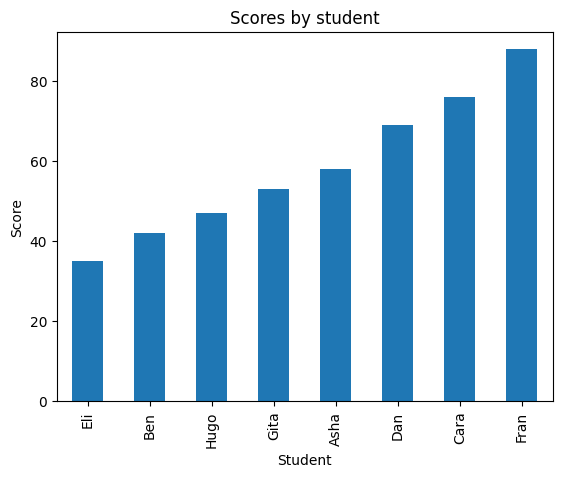

In [30]:
df.sort_values("score").plot.bar(x="student", y="score", legend=False)
plt.title("Scores by student")
plt.xlabel("Student")
plt.ylabel("Score")
plt.show()

The plots suggest that higher study time and more practice questions are associated with higher scores in this tiny dataset.

This does not prove causation. It is just an initial visual pattern.

## What I notice

In this toy dataset:

- students who studied more tended to score more highly
- students who attempted more practice questions also tended to score more highly
- the passing students had higher average study time and higher average scores
- because the dataset is tiny, I should treat these observations as practice rather than evidence

## Why this matters for machine learning

Before training a model, I usually need to understand the data:

- what columns exist
- what types of values they contain
- whether values are missing
- what the rough distributions look like
- whether some columns appear related to the outcome I care about

This notebook is a first pass at that workflow.

In [31]:
df[["hours_studied", "practice_questions", "score"]].corr()

,hours_studied,practice_questions,score
hours_studied,1.000000,0.997694,0.999408
practice_questions,0.997694,1.000000,0.998268
score,0.999408,0.998268,1.000000


Correlation is a numerical summary of how strongly two numeric columns move together.

A value near 1 suggests they tend to increase together.
A value near -1 suggests one tends to decrease as the other increases.
A value near 0 suggests little linear relationship.

Correlation is useful, but it can be misleading if used without context.

## Summary

In this notebook I practised:

- creating a pandas DataFrame
- inspecting rows, columns and data types
- selecting columns
- filtering rows
- sorting values
- creating derived columns
- grouping and summarising data
- making simple plots
- writing plain-English observations

This is the basic exploratory data analysis loop I will use before more formal machine learning work.